## Streaming

.stream() and astream()

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  
import warnings
#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage,AnyMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

## Reducers
from typing import Annotated
from typing import Literal
from langgraph.graph.message import add_messages
import random
from  dataclasses import dataclass
from pydantic import BaseModel
from pprint import pprint
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
warnings.filterwarnings("ignore")

C:\Users\kanha\AppData\Local\Temp\ipykernel_7092\2771377274.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader


In [14]:
import warnings

In [15]:
warnings.filterwarnings("ignore")

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


In [3]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"


In [5]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")

llm.invoke("Hello")

c:\Users\kanha\OneDrive\Documents\RAG practice\.venv\Lib\site-packages\langsmith\client.py:649: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to "Hello". It\'s a greeting. We should greet back. Possibly ask how they can help.'}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 72, 'total_tokens': 117, 'completion_time': 0.045347525, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.003358101, 'prompt_tokens_details': None, 'queue_time': 0.317092026, 'total_time': 0.048705626}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_184f7b52b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fcce2-48fc-7881-8155-0c58e5944024-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 45, 'total_tokens': 117, 'output_token_details': {'reasoning': 25}})

Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fcce2-48fc-7881-8155-0c58e5944024,id=019fcce2-48fc-7881-8155-0c58e5944024


In [11]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

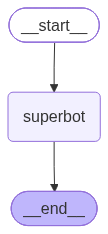

In [12]:
graph=StateGraph(State)
graph.add_node("superbot",superbot)
graph.add_edge(START,"superbot")
graph.add_edge('superbot',END)
graph_builder=graph.compile(checkpointer=memory)
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [ ]:
config={"configurable":{"thread_id":"1"}}
graph_builder.invoke({'messages':"Hi,My name is saksham and i like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is saksham and i like cricket', additional_kwargs={}, response_metadata={}, id='a6247037-0de2-42d0-88cd-cad0833ddfbc'),
  AIMessage(content='Hey Saksham! 👋 It’s great to meet a cricket fan. Which teams or players do you follow the most? Or maybe there’s a particular match or moment that’s your favorite? Let me know—happy to chat about cricket (or anything else you’re into)!', additional_kwargs={'reasoning_content': 'User says "Hi, My name is saksham and i like cricket". We need to respond. The user is greeting and providing info. We can respond warmly, ask about cricket, maybe ask what they like about cricket, or what teams, etc. The user didn\'t ask a question, just introduced. So respond with friendly chat. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 83, 'total_tokens': 222, 'completion_time': 0.157548188, 'completion_tokens_details': {'reasoning_tokens': 73}, 'prompt_time': 0.004031

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fcce8-fb82-7d50-b419-e135ebc7475a,id=019fcce8-fb82-7d50-b419-e135ebc7475a; trace=019fcce8-fb82-7d50-b419-e135ebc7475a,id=019fcce8-fb98-7f33-89a0-e82f378c7e5f; trace=019fcce8-fb82-7d50-b419-e135ebc7475a,id=019fcce8-fb98-7f33-89a0-e83f7573835a
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fcce8-fb82-7d50-b419-e135ebc7475a,id=019fcce8-fb98-7f33-89a0-e83f7573835a; trace=019fcce8-fb82-7d50-b419-e135ebc7475a,id=019fcce8-fb98-7f33-89a0-e82f378c7e5f; trace=019fcce8-

In [ ]:
config={"configurable":{"thread_id":"2"}}
for chunk in graph_builder.stream({'messages':"Hi,My name is saksham and i like cricket"},config,stream_mode="updates"):
    print(chunk)
   


{'superbot': {'messages': [AIMessage(content='Hey Saksham! 👋 It’s awesome that you’re into cricket. Do you have a favorite team, player, or memorable match that you love talking about? I’m all ears!', additional_kwargs={'reasoning_content': 'The user says: "Hi,My name is saksham and i like cricket" repeated. They might just want a greeting. We should respond politely. No policy issues. We can ask about cricket.'}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 168, 'total_tokens': 259, 'completion_time': 0.124448787, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.008240818, 'prompt_tokens_details': None, 'queue_time': 0.282694408, 'total_time': 0.132689605}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3cdd24b83b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fccec-5091-74b3-aa51-20d7dfc2de53-0', tool_calls=[], invalid_tool_calls=[], usage_metadat

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fccec-5086-7663-8923-298a5d8e63ed,id=019fccec-5086-7663-8923-298a5d8e63ed; trace=019fccec-5086-7663-8923-298a5d8e63ed,id=019fccec-5090-7a53-aaed-0c17f1926773; trace=019fccec-5086-7663-8923-298a5d8e63ed,id=019fccec-5091-74b3-aa51-20d7dfc2de53
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fccec-5086-7663-8923-298a5d8e63ed,id=019fccec-5091-74b3-aa51-20d7dfc2de53; trace=019fccec-5086-7663-8923-298a5d8e63ed,id=019fccec-5090-7a53-aaed-0c17f1926773; trace=019fccec-

In [ ]:
config={"configurable":{"thread_id":"2"}}
for chunk in graph_builder.stream({'messages':"Hi,My name is saksham and i like cricket"},config,stream_mode="values"):
    print(chunk)
   


{'messages': [HumanMessage(content='Hi,My name is saksham and i like cricket', additional_kwargs={}, response_metadata={}, id='17648350-73ad-4523-97ee-1968ab727198'), AIMessage(content='Hello Saksham! 👋 It’s great to meet someone who loves cricket. Which team or player do you follow most? Or maybe you’ve got a favorite match or moment that always gets you excited? Let me know—happy to chat about the game, stats, or anything else you’re interested in!', additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hi,My name is saksham and i like cricket". We need to greet and maybe ask about cricket. Also note that the user is not asking a question but introducing themselves. We can respond with a friendly greeting, mention cricket, maybe ask about favorite team or player. Also mention that we are a language model. No policy violation. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 155, 'prompt_tokens': 83, 'total_tokens': 238, 'completion_time'

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fccee-f65e-7163-8b04-212db00b237a,id=019fccee-f65e-7163-8b04-212db00b237a; trace=019fccee-f65e-7163-8b04-212db00b237a,id=019fccee-f66b-7e82-a056-efed4892c78b; trace=019fccee-f65e-7163-8b04-212db00b237a,id=019fccee-f66b-7e82-a056-eff0fe351a33
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fccee-f65e-7163-8b04-212db00b237a,id=019fccee-f66b-7e82-a056-eff0fe351a33; trace=019fccee-f65e-7163-8b04-212db00b237a,id=019fccee-f66b-7e82-a056-efed4892c78b; trace=019fccee-

In [ ]:

for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is saksham and i like cricket', additional_kwargs={}, response_metadata={}, id='17648350-73ad-4523-97ee-1968ab727198'), AIMessage(content='Hello Saksham! 👋 It’s great to meet someone who loves cricket. Which team or player do you follow most? Or maybe you’ve got a favorite match or moment that always gets you excited? Let me know—happy to chat about the game, stats, or anything else you’re interested in!', additional_kwargs={'reasoning_content': 'We need to respond. The user says: "Hi,My name is saksham and i like cricket". We need to greet and maybe ask about cricket. Also note that the user is not asking a question but introducing themselves. We can respond with a friendly greeting, mention cricket, maybe ask about favorite team or player. Also mention that we are a language model. No policy violation. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 155, 'prompt_tokens': 83, 'total_tokens': 238, 'completion_time'

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fccef-090b-7251-bf9b-7e63bf40ac49,id=019fccef-090b-7251-bf9b-7e63bf40ac49; trace=019fccef-090b-7251-bf9b-7e63bf40ac49,id=019fccef-091b-7b81-be0e-e830f683797f; trace=019fccef-090b-7251-bf9b-7e63bf40ac49,id=019fccef-091c-71a1-8394-50ea160218b6
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fccef-090b-7251-bf9b-7e63bf40ac49,id=019fccef-091c-71a1-8394-50ea160218b6; trace=019fccef-090b-7251-bf9b-7e63bf40ac49,id=019fccef-091b-7b81-be0e-e830f683797f; trace=019fccef-

# Astream

In [ ]:
config={"configurable":{"thread_id":"3"}}
async for event in graph_builder.astream_events({'messages':["Hi my name is saksham and i like to play cricket"]},config,version="v2"):
    print(event)


{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi my name is saksham and i like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fce09-ac80-7f31-ae67-a9baec1406bd', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is saksham and i like to play cricket', additional_kwargs={}, response_metadata={}, id='0e68369d-d34f-4dff-9d54-07d03fbfcdc9')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019fce09-aca1-7e73-a57d-30bd5b2aa3f7', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:8aed525c-af1e-83d6-2ce5-14c97af4dfdc'}, 'parent_ids': ['019fce09-ac80-7f31-ae67-a9baec1406bd']}
{'event': 'on_chat_model_start', 'data': {'input': {'messag

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fce09-ac80-7f31-ae67-a9baec1406bd,id=019fce09-ac80-7f31-ae67-a9baec1406bd; trace=019fce09-ac80-7f31-ae67-a9baec1406bd,id=019fce09-aca1-7e73-a57d-30bd5b2aa3f7; trace=019fce09-ac80-7f31-ae67-a9baec1406bd,id=019fce09-aca5-7701-9282-fdde9ae77eaf
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019fce09-ac80-7f31-ae67-a9baec1406bd,id=019fce09-aca5-7701-9282-fdde9ae77eaf; trace=019fce09-ac80-7f31-ae67-a9baec1406bd,id=019fce09-aca1-7e73-a57d-30bd5b2aa3f7; trace=019fce09-